In [1]:
import common_functions

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-06-29.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-07-01.nc")
control_ds_dust_sites = xr.open_dataset("DATA/processed/5_control_grid_dust_sites_2026-06-22.nc")

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

## Surface categories

In [3]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
soil_order_dict = common_functions.get_soil_order_names_major()
soil_order_colors = common_functions.get_soil_order_colors_major()

In [4]:
#--- Using the normalized frequency of how often wind speeds exceed 10 m/s

domain_size = len(control_ds['lat']) * len(control_ds['lon'])
domain_freq = (control_ds['wind_speed'] >= 10).sum().item()
domain_winds_per_pixel = domain_freq / domain_size

def wind_freq_by_category(ds, category_dict, category_name):
    categories = list(category_dict.keys())

    wind_freqs = []

    for k in categories:
        filtered_ds = ds.where(ds[category_name] == k)
        category_size = filtered_ds[category_name].count(dim=['lat', 'lon']).item()
        category_freq = (filtered_ds['wind_speed'] >= 10).sum().item()
        category_winds_per_pixel = (category_freq / category_size if category_size != 0 else np.nan)
        category_winds_per_pixel_normalized = category_winds_per_pixel / domain_winds_per_pixel

        # print(f"{category_dict[k]}: {wind_freq_category:.2f}")
        # print(f"{category_dict[k]}: {category_freq}/{category_size} = {category_winds_per_pixel:.2f}/{domain_winds_per_pixel:.2f} = {category_winds_per_pixel_normalized:.2f}")
        wind_freqs.append(category_winds_per_pixel_normalized)

    return wind_freqs

wind_freqs = wind_freq_by_category(ds=control_ds, category_dict=texture_dict, category_name='soil_texture')

In [5]:
categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]

non_dust_counts = [np.sum(control_ds["soil_texture"] == k).values for k in texture_dict.keys()]
non_dust_total = sum(non_dust_counts)
non_dust_fraction = np.array([count / non_dust_total for count in non_dust_counts])*100

dust_counts = [np.sum(dust_df["texture"] == k) for k in texture_dict.keys()]
dust_total = sum(dust_counts)
dust_fraction = np.array([count / dust_total for count in dust_counts])*100

dust_representation = dust_fraction/non_dust_fraction

texture_df = pd.DataFrame({
    "Surface Category": labels,
    "Domain Frequency": np.round(non_dust_fraction,2),
    "Dust Frequency": np.round(dust_fraction, 2), 
    "Dust Representation": np.round(dust_representation, 2),
    "Relative Wind Exposure": np.round(wind_freqs, 2)
})

texture_df

/tmp/ipykernel_2447493/603129957.py:12: RuntimeWarning: invalid value encountered in divide
  dust_representation = dust_fraction/non_dust_fraction


,Surface Category,Domain Frequency,Dust Frequency,Dust Representation,Relative Wind Exposure
0,Sand,6.09,11.78,1.93,1.48
1,Loamy Sand,1.77,2.52,1.42,1.15
2,Sandy Loam,28.01,24.04,0.86,1.41
3,Silt Loam,6.46,4.47,0.69,1.52
4,Silt,0.00,0.00,NaN,NaN
5,Loam,42.50,28.88,0.68,1.43
6,Sandy Clay Loam,4.61,12.12,2.63,0.74
7,Silty Clay Loam,2.06,1.89,0.92,1.35
8,Clay Loam,3.62,2.21,0.61,1.26
9,Sandy Clay,0.13,0.00,0.00,0.68


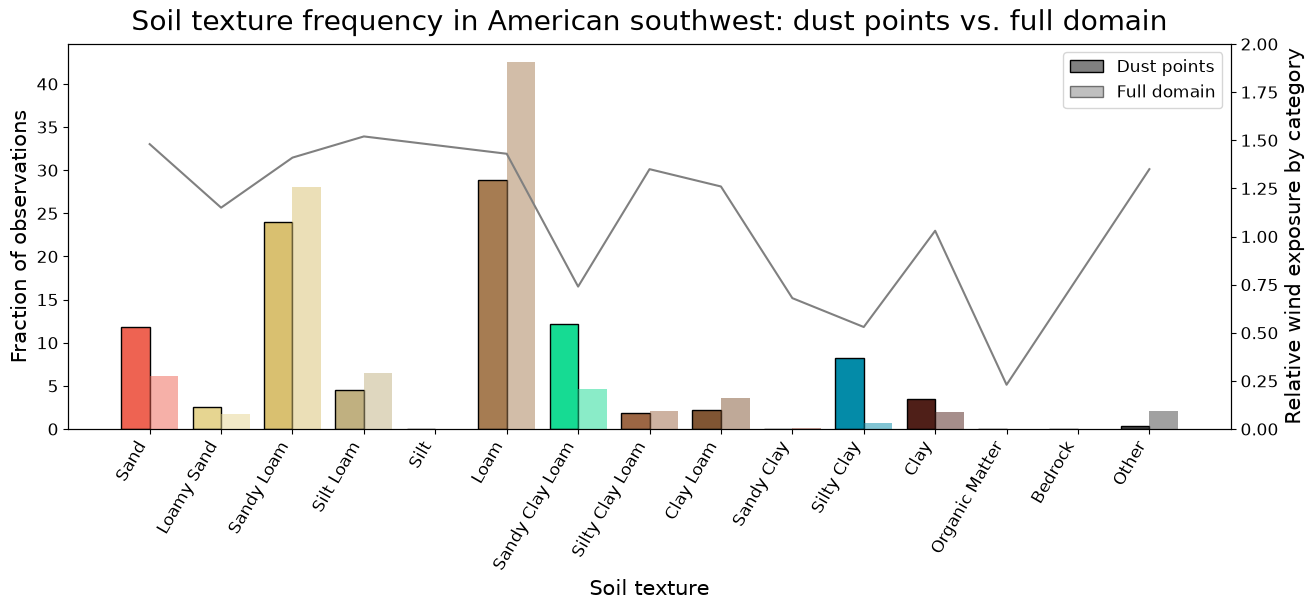

In [6]:
x = np.arange(len(texture_df))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))

for i in x:
    color = texture_colors[i]
    ax.bar(i - width / 2, texture_df['Dust Frequency'][i], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(i + width / 2, texture_df['Domain Frequency'][i], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")


ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = texture_df['Relative Wind Exposure'].interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(0,2)
ax2.set_ylabel("Relative wind exposure by category", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [7]:
#--- Manually setting order of categories
chosen_categories = [7, 15, 8, 16, 9, 10, 14, 17, 1, 18, 5, 3, 6, 19]
labels = [land_cover_dict[k] for k in chosen_categories]
chosen_land_cover_dict = dict(zip(chosen_categories, labels))

mean_freqs = wind_freq_by_category(ds=control_ds, category_dict=chosen_land_cover_dict, category_name='usage')

In [8]:
non_dust_counts = [np.sum(control_ds["usage"] == k).values for k in chosen_categories]
non_dust_total = sum(non_dust_counts)
non_dust_fraction = np.array([count / non_dust_total for count in non_dust_counts])*100

dust_counts = [np.sum(dust_df["usage"] == k) for k in chosen_categories]
dust_total = sum(dust_counts)
dust_fraction = np.array([count / dust_total for count in dust_counts])*100

dust_representation = dust_fraction/non_dust_fraction

surface_cover_df = pd.DataFrame({
    "Surface Category": labels,
    "Domain Frequency": np.round(non_dust_fraction,2),
    "Dust Frequency": np.round(dust_fraction, 2), 
    "Dust Representation": np.round(dust_representation, 2),
    "Relative Wind Exposure": np.round(mean_freqs, 2)
})

surface_cover_df

,Surface Category,Domain Frequency,Dust Frequency,Dust Representation,Relative Wind Exposure
0,Tropical/Sub-tropical Shrubland,21.01,19.87,0.95,0.78
1,Cropland,8.44,17.90,2.12,1.23
2,Temp/Sub-polar Shrubland,30.57,15.46,0.51,1.42
3,Barren Lands,2.27,15.15,6.67,0.79
4,Tropical/Sub-tropical Grassland,2.97,13.40,4.51,0.81
5,Temp/Sub-polar Grassland,15.80,12.94,0.82,1.28
6,Wetland,1.11,2.32,2.08,1.39
7,Urban and Built-up,2.41,1.52,0.63,0.91
8,Temp/Sub-polar Needleleaf Forest,11.78,0.40,0.03,1.86
9,Water,0.58,0.52,0.89,1.06


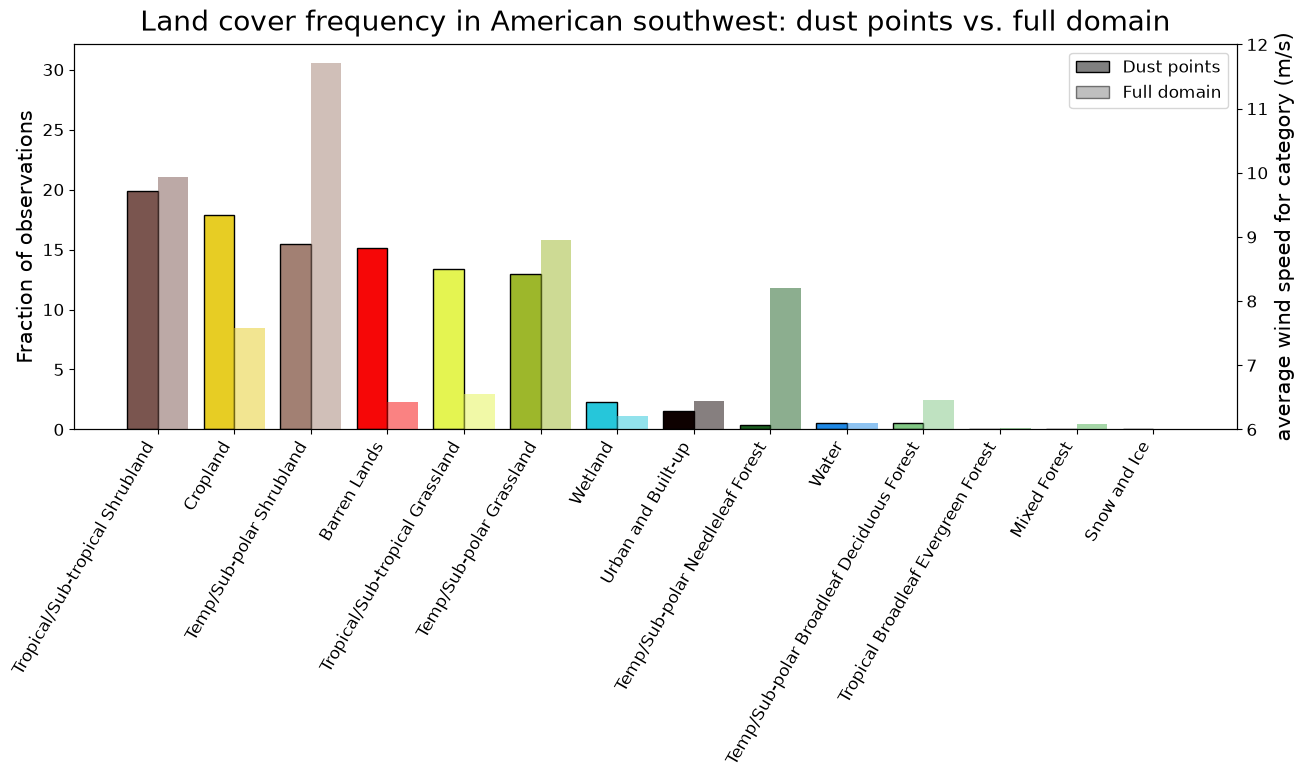

In [9]:
#--- Manually set list of categories earlier
x = np.arange(len(chosen_categories))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))

for i in x:
    color = land_cover_colors[chosen_categories[i]]
    ax.bar(i - width / 2, surface_cover_df['Dust Frequency'][i], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(i + width / 2, surface_cover_df['Domain Frequency'][i], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

ax.tick_params(labelsize=12)
labels = [land_cover_dict[k] for k in chosen_categories]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
# ax.set_xlabel("Land cover", fontsize=15)
ax.set_title(f"Land cover frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = pd.Series(surface_cover_df['Relative Wind Exposure']).interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(6,12)
ax2.set_ylabel("average wind speed for category (m/s)", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/5_land_cover_cec_2_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [10]:
#--- Manually setting order of categories
chosen_categories = [2, 3, 7, 0, 15, 14, 13, 4, 5, 11, 10, 6]
labels = [soil_order_dict[k] for k in chosen_categories]
chosen_soil_order_dict = dict(zip(chosen_categories, labels))

mean_freqs = wind_freq_by_category(ds=control_ds, category_dict=chosen_soil_order_dict, category_name='soil_order')

In [11]:
non_dust_counts = [np.sum(control_ds["soil_order"] == k).values for k in chosen_categories]
non_dust_total = sum(non_dust_counts)
non_dust_fraction = np.array([count / non_dust_total for count in non_dust_counts])*100

dust_counts = [np.sum(dust_df["soil_order"] == k) for k in chosen_categories]
dust_total = sum(dust_counts)
dust_fraction = np.array([count / dust_total for count in dust_counts])*100

dust_representation = dust_fraction/non_dust_fraction

soil_order_df = pd.DataFrame({
    "Surface Category": labels,
    "Domain Frequency": np.round(non_dust_fraction,2),
    "Dust Frequency": np.round(dust_fraction, 2), 
    "Dust Representation": np.round(dust_representation, 2),
    "Relative Wind Exposure": np.round(mean_freqs, 2)
})

soil_order_df

/tmp/ipykernel_2447493/3587224846.py:9: RuntimeWarning: invalid value encountered in divide
  dust_representation = dust_fraction/non_dust_fraction


,Surface Category,Domain Frequency,Dust Frequency,Dust Representation,Relative Wind Exposure
0,Aridisols,38.52,41.21,1.07,1.17
1,Entisols,23.51,37.51,1.60,1.10
2,Mollisols,24.26,11.37,0.47,1.72
3,Alfisols,10.06,7.22,0.72,1.79
4,Water,0.48,0.06,0.12,0.63
5,Shifting Sands,0.23,1.72,7.61,2.52
6,Salt flats,0.33,0.34,1.04,0.41
7,Gelisols,0.85,0.03,0.03,3.69
8,Histosols,0.00,0.00,NaN,NaN
9,Vertisols,0.54,0.54,1.02,0.19


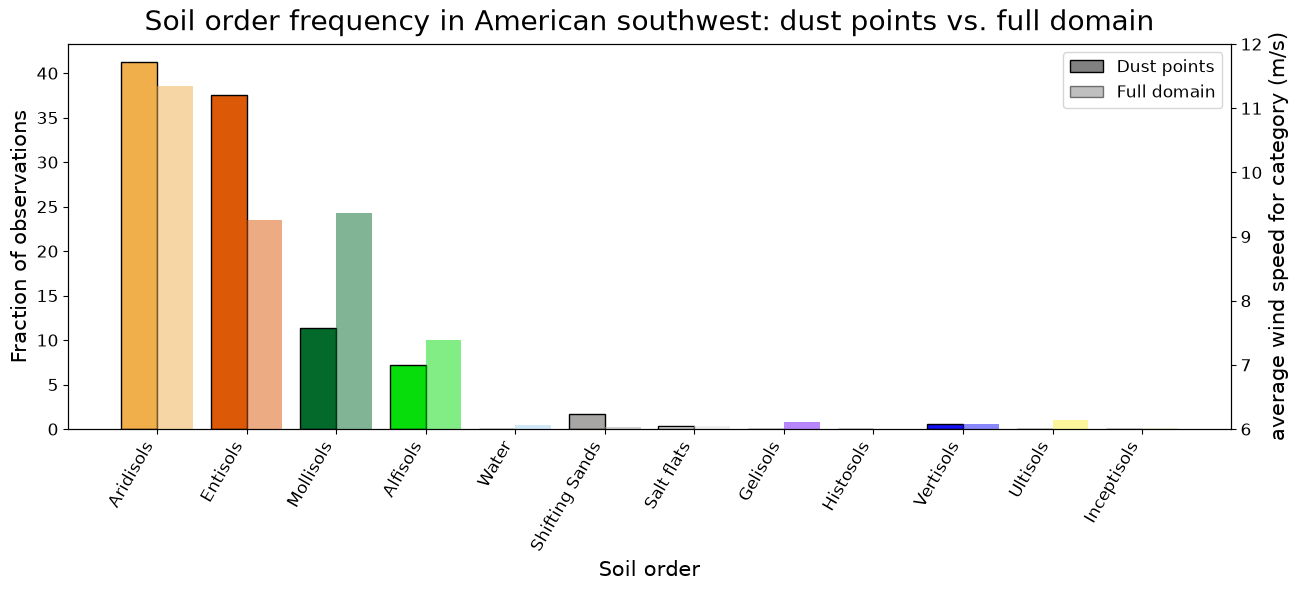

In [12]:
x = np.arange(len(chosen_categories))
labels = [soil_order_dict[k] for k in chosen_categories]
width = 0.4

fig, ax = plt.subplots(figsize=(15, 5))

for i in x:
    color = soil_order_colors[chosen_categories[i]]
    ax.bar(i - width / 2, soil_order_df['Dust Frequency'][i], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(i + width / 2, soil_order_df['Domain Frequency'][i], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")

ax.tick_params(labelsize=12)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil order", fontsize=15)
ax.set_title(f"Soil order frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

#--- Line for wind average by category

ax2 = ax.twinx()
y_clean = pd.Series(soil_order_df['Relative Wind Exposure']).interpolate() #--- Interpolate over NaN values
ax2.plot(x, y_clean, c="grey")
ax2.tick_params(labelsize=12)
ax2.set_ylim(6,12)
ax2.set_ylabel("average wind speed for category (m/s)", fontsize=15)

#--- Add legend

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/4_soil_types_usda_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [13]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

## Continuous (wind and moisture)

Plotting wind speed bar chart...


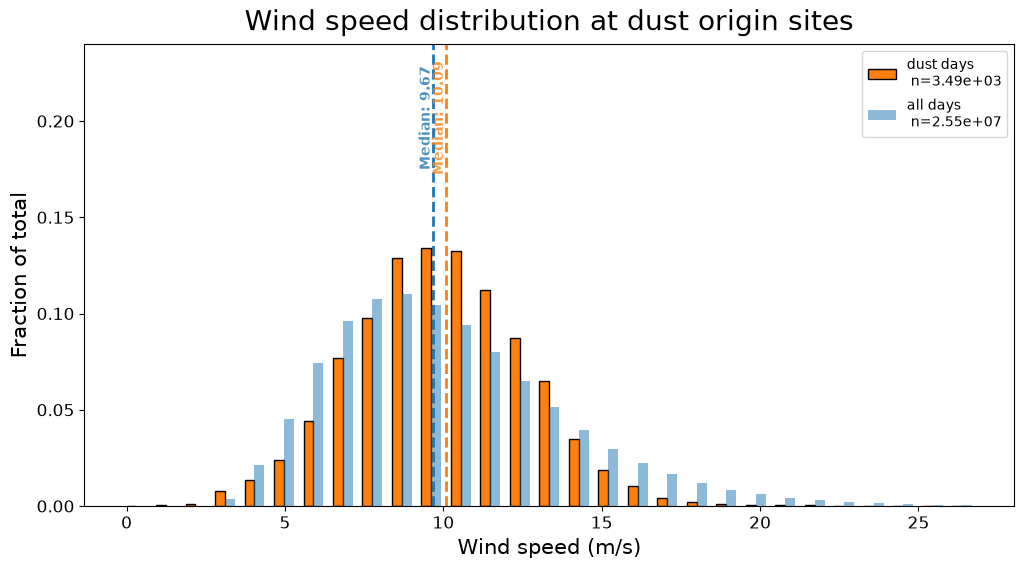

In [14]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust_days, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds_dust_sites["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds_dust_sites["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


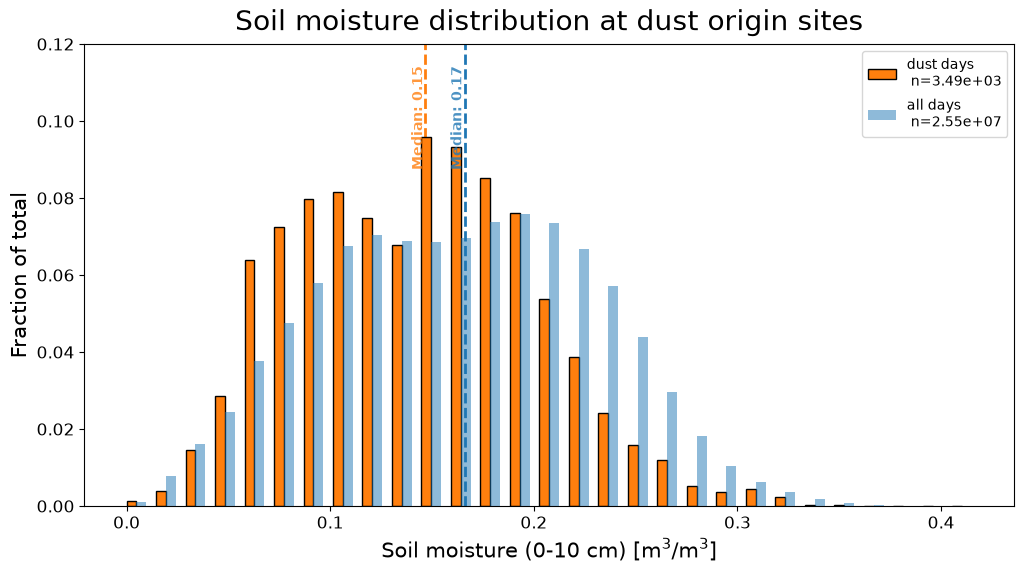

In [15]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust_days, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds_dust_sites["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Combined surface categories

In [16]:
combo_three_ds = xr.open_dataset("DATA/processed/7_surface_combo_dust_2026-07-01.nc")

In [17]:
#--- Apply dictionaries to get the category names

land_cover_dict = common_functions.get_land_cover_dict()
soil_order_dict = common_functions.get_soil_order_names_major()
texture_dict = common_functions.get_texture_dict()

combo_three_ds["combo_id"] = combo_three_ds["combo_id"].astype(int)

def decode_combo_id(combo_id):
    texture = combo_id // 1_000_000
    soil_order = (combo_id % 1_000_000) // 1_000
    surface_cover = combo_id % 1_000
    return texture, soil_order, surface_cover

def combo_id_to_label(combo_id):
    texture, soil, cover = decode_combo_id(combo_id)

    return (
        texture_dict.get(texture, f"Unknown({texture})"),
        soil_order_dict.get(soil, f"Unknown({soil})"),
        land_cover_dict.get(cover, f"Unknown({cover})")
    )

/home/jturner/WLDAS_Analysis/wldas_venv/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [18]:
combo_three_df = combo_three_ds[["combo_id", "dust_event_count", "wind_speed"]].to_dataframe().reset_index()

#--- Remove the null row
combo_three_df = combo_three_df[combo_three_df["combo_id"] != -9223372036854775808]

grouped = combo_three_df.groupby("combo_id").agg(
    dust_event_count=("dust_event_count", "sum"),
    full_domain=("combo_id", "size"),
)

grouped = grouped.sort_values("dust_event_count", ascending=False)

decoded = [
    (cid, *combo_id_to_label(cid), row.dust_event_count, row.full_domain)
    for cid, row in grouped.iterrows()
]

top_df = pd.DataFrame(
    decoded,
    columns=["combo_id", "texture", "soil_order", "surface_cover", "dust_events", "full_domain"]
)

top_df["dust_fraction"] = (
    top_df["dust_events"] / top_df["dust_events"].sum()
)

top_df["full_domain_fraction"] = (
    top_df["full_domain"] / top_df["full_domain"].sum()
)

top_df

KeyboardInterrupt: 

In [ ]:
import sys
sys.exit()

In [ ]:
print("Getting relative wind exposure by category...")

#--- The wind is not included in top_df, because that was very slow to run
#--- Maybe run it separately

domain_size = len(control_ds['lat']) * len(control_ds['lon'])
domain_freq = (control_ds['wind_speed'] >= 10).sum().item()
domain_winds_per_pixel = domain_freq / domain_size


filtered_ds = ds.where(ds[category_name] == k)
category_size = filtered_ds[category_name].count(dim=['lat', 'lon']).item()
category_freq = (filtered_ds['wind_speed'] >= 10).sum().item()
category_winds_per_pixel = (category_freq / category_size if category_size != 0 else np.nan)
category_winds_per_pixel_normalized = category_winds_per_pixel / domain_winds_per_pixel

Getting relative wind exposure by category...


KeyError: 'wind_speed'

In [ ]:
top_10_df = top_df[:10]

labels = []
for i in range(10):
    name = f"{top_10_df.iloc[i]['texture']} -- {top_10_df.iloc[i]['soil_order']} -- {top_10_df.iloc[i]['surface_cover']}"
    labels.append(name)

soil_order_df = pd.DataFrame({
    "Surface Category": labels,
    "Domain Frequency": np.round(top_10_df["full_domain_fraction"]*100,2),
    "Dust Frequency": np.round(top_10_df["dust_fraction"]*100, 2), 
    "Dust Representation": np.round((top_10_df["dust_fraction"]*100)/(top_10_df["full_domain_fraction"]*100), 2),
    # "Relative Wind Exposure": np.round(mean_freqs, 2)
})

soil_order_df

,Surface Category,Domain Frequency,Dust Frequency,Dust Representation
0,Silty Clay -- Entisols -- Barren Lands,0.04,5.01,142.67
1,Loam -- Entisols -- Tropical/Sub-tropical Gras...,0.64,4.41,6.90
2,Loam -- Aridisols -- Tropical/Sub-tropical Shr...,5.26,3.98,0.76
3,Loam -- Entisols -- Tropical/Sub-tropical Shru...,4.79,3.52,0.74
4,Sand -- Aridisols -- Temp/Sub-polar Shrubland,0.83,3.35,4.04
5,Sandy Loam -- Aridisols -- Tropical/Sub-tropic...,3.55,3.27,0.92
6,Sandy Loam -- Aridisols -- Temp/Sub-polar Shru...,5.16,3.21,0.62
7,Sandy Clay Loam -- Entisols -- Tropical/Sub-tr...,1.22,2.87,2.35
8,Sandy Loam -- Alfisols -- Cropland,0.60,2.78,4.65
9,Sandy Clay Loam -- Entisols -- Tropical/Sub-tr...,0.15,2.72,18.39


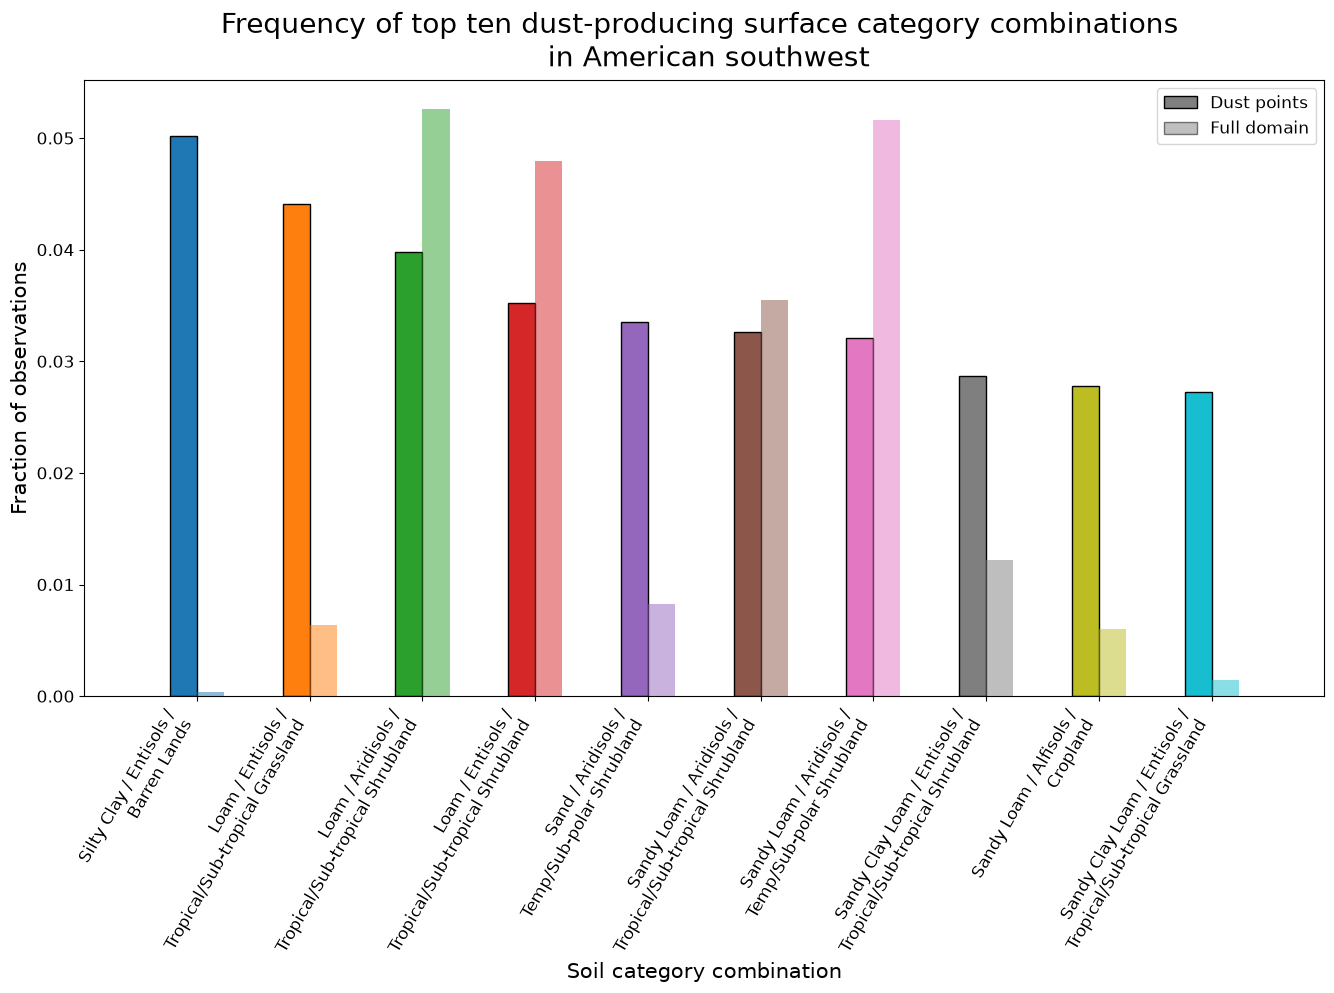

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(top_10_df))
width = 0.24
x_labels = []

cmap = plt.cm.tab10
colors = cmap(np.linspace(0, 1, len(top_10_df)))

for i in np.arange(len(top_10_df)):
    ax.bar(
        x[i] - width/2,
        top_10_df['dust_fraction'][i],
        width=width,
        color=colors[i],
        edgecolor="black",
        label="Dust points" if i == 0 else None
    )
    ax.bar(
        x[i] + width/2,
        top_10_df['full_domain_fraction'][i],
        width=width,
        color=colors[i],
        alpha=0.5,
        edgecolor=None,
        label="Full domain" if i == 0 else None
    )
    x_labels.append(
        f"{top_10_df['texture'][i]} / "
        f"{top_10_df['soil_order'][i]} /\n"
        f"{top_10_df['surface_cover'][i]}"
    )

ax.set_xticks(x)
ax.tick_params(labelsize=12)
ax.set_xticklabels(x_labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlim(-1, len(top_10_df))
ax.set_xlabel("Soil category combination", fontsize=15)
ax.set_title(f"Frequency of top ten dust-producing surface category combinations \n in American southwest", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/6_combination_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()